In [1]:
import pandas as pd
import requests
import plotly.express as px

In [2]:
url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

response = requests.get(url)

In [3]:
print("Status Code:", response.status_code)

Status Code: 200


In [4]:
data = response.json()

In [6]:
print(type(data))

<class 'list'>


In [7]:
print(data[0])  # Print the first entry in the data list

['time_tag', 'density', 'speed', 'temperature']


In [8]:
print("Rows:", len(data))
print("Header:", data[0])
print("First Record:", data[1])

Rows: 9196
Header: ['time_tag', 'density', 'speed', 'temperature']
First Record: ['2026-06-13 10:48:00.000', '0.93', '415.4', '32068']


In [9]:
headers = data[0]
rows = data[1:]

In [10]:
df = pd.DataFrame(rows, columns=headers)

In [11]:
df["density"] = pd.to_numeric(df["density"])
df["speed"] = pd.to_numeric(df["speed"])
df["temperature"] = pd.to_numeric(df["temperature"])

df["time_tag"] = pd.to_datetime(df["time_tag"])

In [12]:
df.head()

,time_tag,density,speed,temperature
0,2026-06-13 10:48:00,0.93,415.4,32068
1,2026-06-13 10:49:00,0.32,515.4,2000
2,2026-06-13 10:50:00,0.60,456.7,19133
3,2026-06-13 10:51:00,0.84,417.3,32521
4,2026-06-13 10:52:00,0.81,410.3,32257


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9195 entries, 0 to 9194
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9195 non-null   datetime64[us]
 1   density      9195 non-null   float64       
 2   speed        9195 non-null   float64       
 3   temperature  9195 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 287.5 KB
None


In [14]:
print(df.describe())


                         time_tag      density       speed    temperature
count                        9195  9195.000000  9195.00000    9195.000000
mean   2026-06-17 02:20:11.060359     6.531647   435.16472  112459.526482
min           2026-06-13 10:48:00     0.090000   356.70000    2000.000000
25%           2026-06-15 11:21:30     5.100000   402.80000   58238.000000
50%           2026-06-17 03:47:00     6.400000   430.40000   98823.000000
75%           2026-06-18 19:48:30     8.170000   462.70000  152045.500000
max           2026-06-20 10:44:00    17.490000   606.90000  552298.000000
std                           NaN     2.766844    43.97794   78940.578166


In [16]:
print(df["density"].describe())
print(df["speed"].describe())
print(df["temperature"].describe())

count    9195.000000
mean        6.531647
std         2.766844
min         0.090000
25%         5.100000
50%         6.400000
75%         8.170000
max        17.490000
Name: density, dtype: float64
count    9195.00000
mean      435.16472
std        43.97794
min       356.70000
25%       402.80000
50%       430.40000
75%       462.70000
max       606.90000
Name: speed, dtype: float64
count      9195.000000
mean     112459.526482
std       78940.578166
min        2000.000000
25%       58238.000000
50%       98823.000000
75%      152045.500000
max      552298.000000
Name: temperature, dtype: float64


In [17]:
fig = px.line(
    df,
    x="time_tag",
    y = "density",
    title = "Solar Wind Density - Last 7 Days"
)

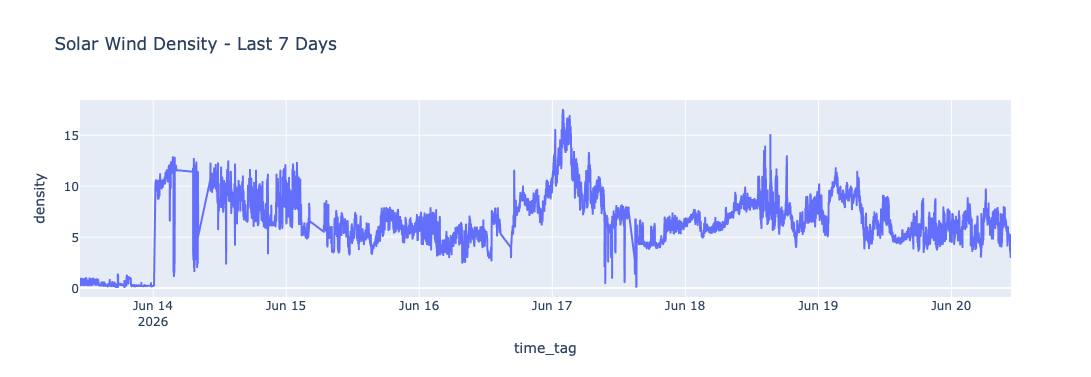

In [18]:
fig

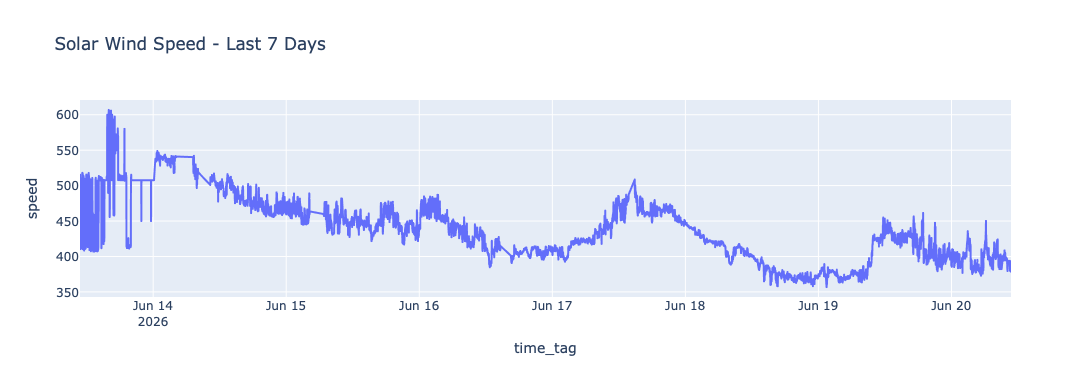

In [19]:
fig = px.line(
    df,
    x="time_tag",
    y = "speed",
    title = "Solar Wind Speed - Last 7 Days"
)

fig

In [20]:
print(df.loc[df["speed"].idxmax()])
print(df.loc[df["density"].idxmax()])
print(df.loc[df["temperature"].idxmax()])

time_tag       2026-06-13 15:59:00
density                       0.27
speed                        606.9
temperature                   8092
Name: 311, dtype: object
time_tag       2026-06-17 01:55:00
density                      17.49
speed                        403.2
temperature                  73222
Name: 4485, dtype: object
time_tag       2026-06-14 03:33:00
density                      12.85
speed                        530.7
temperature                 552298
Name: 864, dtype: object


In [21]:
print(
    df[["density", "speed", "temperature"]].corr()
)

              density     speed  temperature
density      1.000000 -0.187737     0.344583
speed       -0.187737  1.000000     0.523604
temperature  0.344583  0.523604     1.000000
